# CS-4063 NLP — Assignment 3: Transformers + RAG



## System Overview
```
Raw Reviews
    │
    ▼
[Preprocessing] → tokenise, vocab, pad/truncate
    │
    ▼
[Part A] Encoder-only Transformer
    ├── Task 1: Sentiment classification  (Neg / Neu / Pos)
    ├── Task 2: Review length prediction  (Short / Medium / Long)
    └── Output: fixed-dim review embeddings  →  saved to disk
    │
    ▼
[Part B] Retrieval Module
    └── Cosine similarity search over training embeddings → top-k neighbours
    │
    ▼
[Part C] Decoder-only Transformer
    └── Autoregressive explanation generation conditioned on
        (review + sentiment + length-class + retrieved context)
```

---
## 0. Imports & Setup

In [8]:
import os, json, gzip, math, random, re, time, pickle
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')   # CPU-only training
print(f'Using device: {DEVICE}')

# ── Directory setup ────────────────────────────────────────────────────────────
for d in ['data/raw', 'data/processed', 'models', 'results']:
    Path(d).mkdir(parents=True, exist_ok=True)

print('Directories ready.')

Using device: cpu
Directories ready.


---
## 1. Dataset Loading

We load reviews from **at least 3 product categories** and sample ~10–15k per category,
targeting a final dataset of 30k–45k samples as required by the assignment.

In [17]:
# ── Configuration ──────────────────────────────────────────────────────────────
CATEGORY_FILES = {
    'Electronics': '/content/data/raw/Electronics.txt',
    'Sports':      '/content/data/raw/Sports_&_Outdoors.txt',
    'Clothing':    '/content/data/raw/Clothing_&_Accessories.txt',
}
SAMPLES_PER_CATEGORY = 12000   # ~36k total → within 30k–45k range

def load_category(filepath: str, n: int) -> list:
    """Load Amazon reviews in key-value block format."""
    records = []
    opener = gzip.open if filepath.endswith('.gz') else open
    with opener(filepath, 'rt', encoding='utf-8', errors='ignore') as f:
        current = {}
        for line in f:
            line = line.strip()
            if line == '':
                # blank line = end of one review block
                text   = current.get('review/text', '').strip()
                rating = current.get('review/score', None)
                if text and rating and len(text) > 10:
                    try:
                        records.append({'text': text, 'rating': int(float(rating))})
                    except Exception:
                        pass
                current = {}
                if len(records) >= n:
                    break
            else:
                if ': ' in line:
                    key, _, value = line.partition(': ')
                    current[key] = value
    return records

all_records = []
for cat, path in CATEGORY_FILES.items():
    print(f'Loading {cat}...', end=' ')
    recs = load_category(path, SAMPLES_PER_CATEGORY)
    for r in recs:
        r['category'] = cat
    all_records.extend(recs)
    print(f'{len(recs)} records loaded.')

if not all_records:
    raise ValueError('No records loaded! Check your file paths and format.')

df = pd.DataFrame(all_records)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle
print(f'\nTotal records: {len(df)}')
print(df['rating'].value_counts().sort_index())

Loading Electronics... 12000 records loaded.
Loading Sports... 12000 records loaded.
Loading Clothing... 12000 records loaded.

Total records: 36000
rating
1     3386
2     2027
3     3090
4     7184
5    20313
Name: count, dtype: int64


---
## 2. Preprocessing Pipeline

Steps :
1. **Text cleaning** — lowercase, remove HTML tags, strip excess whitespace
2. **Tokenisation** — whitespace + punctuation split
3. **Vocabulary construction** — from training split only
4. **Token → index mapping**
5. **Label derivation** — sentiment (3-class) and review-length (3-class)
6. **Padding / truncation** to a fixed `MAX_SEQ_LEN`

In [18]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
MAX_SEQ_LEN  = 128
MIN_FREQ     = 3       # minimum token frequency to enter vocabulary
VOCAB_SIZE   = 20000   # cap vocab at this size (most-frequent kept)

# Special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

# ── Label derivation ───────────────────────────────────────────────────────────
def rating_to_sentiment(r: int) -> int:
    """0=Negative (1-2), 1=Neutral (3), 2=Positive (4-5)"""
    if r <= 2: return 0
    if r == 3: return 1
    return 2

def text_to_length_class(text: str) -> int:
    """0=Short (<50 words), 1=Medium (50-150), 2=Long (>150)"""
    n = len(text.split())
    if n < 50:  return 0
    if n <= 150: return 1
    return 2

df['sentiment']    = df['rating'].apply(rating_to_sentiment)
df['length_class'] = df['text'].apply(text_to_length_class)

print('Sentiment distribution:')
print(df['sentiment'].value_counts().sort_index().rename({0:'Negative',1:'Neutral',2:'Positive'}))
print('\nLength class distribution:')
print(df['length_class'].value_counts().sort_index().rename({0:'Short',1:'Medium',2:'Long'}))

Sentiment distribution:
sentiment
Negative     5413
Neutral      3090
Positive    27497
Name: count, dtype: int64

Length class distribution:
length_class
Short     18173
Medium    13428
Long       4399
Name: count, dtype: int64


In [19]:
# ── Train / Val / Test split  (70 / 15 / 15) ──────────────────────────────────
n      = len(df)
n_tr   = int(0.70 * n)
n_val  = int(0.15 * n)

train_df = df.iloc[:n_tr].reset_index(drop=True)
val_df   = df.iloc[n_tr:n_tr+n_val].reset_index(drop=True)
test_df  = df.iloc[n_tr+n_val:].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 25200 | Val: 5400 | Test: 5400


In [20]:
# ── Text cleaning ──────────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML tags
    text = re.sub(r'[^a-z0-9\'\s]', ' ', text)   # keep letters, digits, apostrophes
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Tokenisation ───────────────────────────────────────────────────────────────
def tokenize(text: str) -> list:
    return clean_text(text).split()

# ── Vocabulary construction (training data ONLY) ───────────────────────────────
class Vocabulary:
    def __init__(self, special_tokens=SPECIAL_TOKENS):
        self.token2idx = {}
        self.idx2token = {}
        for tok in special_tokens:
            self._add(tok)

    def _add(self, token):
        if token not in self.token2idx:
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx]   = token

    def build(self, texts, min_freq=MIN_FREQ, max_size=VOCAB_SIZE):
        counter = Counter()
        for text in tqdm(texts, desc='Building vocab'):
            counter.update(tokenize(text))
        # keep most-frequent tokens up to max_size (minus special tokens)
        n_special = len(self.token2idx)
        for token, freq in counter.most_common(max_size - n_special):
            if freq >= min_freq:
                self._add(token)
        print(f'Vocabulary size: {len(self.token2idx)}')

    def encode(self, text, max_len=MAX_SEQ_LEN):
        tokens = tokenize(text)[:max_len]
        ids    = [self.token2idx.get(t, self.token2idx[UNK_TOKEN]) for t in tokens]
        # pad
        pad_id = self.token2idx[PAD_TOKEN]
        ids   += [pad_id] * (max_len - len(ids))
        return ids

    def __len__(self):
        return len(self.token2idx)

vocab = Vocabulary()
vocab.build(train_df['text'].tolist())

# Save vocab
with open('data/processed/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print('Vocabulary saved.')

Building vocab: 100%|██████████| 25200/25200 [00:01<00:00, 14671.20it/s]


Vocabulary size: 14329
Vocabulary saved.


In [21]:
# ── PyTorch Dataset ────────────────────────────────────────────────────────────
class ReviewDataset(Dataset):
    def __init__(self, dataframe, vocab, max_len=MAX_SEQ_LEN):
        self.df      = dataframe
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ids = torch.tensor(self.vocab.encode(row['text'], self.max_len), dtype=torch.long)
        # attention mask: 1 for real tokens, 0 for padding
        mask = (ids != self.vocab.token2idx[PAD_TOKEN]).long()
        sent = torch.tensor(row['sentiment'],    dtype=torch.long)
        lenc = torch.tensor(row['length_class'], dtype=torch.long)
        return ids, mask, sent, lenc

BATCH_SIZE = 32

train_ds = ReviewDataset(train_df, vocab)
val_ds   = ReviewDataset(val_df,   vocab)
test_ds  = ReviewDataset(test_df,  vocab)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 788 | Val batches: 169 | Test batches: 169


---
## Part A — Encoder-only Transformer

### Architecture
Built — no `nn.Transformer`, `nn.MultiheadAttention`, etc.

Components:
- **Token + Positional Embeddings**
- **Scaled Dot-Product Attention**
- **Multi-Head Attention**
- **Encoder Block** (Attention → Add&Norm → FFN → Add&Norm)
- **Stacked Encoder**
- **Multi-task classification heads** (sentiment + length-class)

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
#  A1. Scaled Dot-Product Attention
# ─────────────────────────────────────────────────────────────────────────────
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Args:
        Q : (batch, heads, seq, d_k)
        K : (batch, heads, seq, d_k)
        V : (batch, heads, seq, d_v)
        mask: (batch, 1, 1, seq) — 0 for padding positions
    Returns:
        output : (batch, heads, seq, d_v)
        weights: (batch, heads, seq, seq)
    """
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B, H, S, S)

    if mask is not None:
        # mask=0 → fill with large negative so softmax → ~0
        scores = scores.masked_fill(mask == 0, -1e9)

    weights = F.softmax(scores, dim=-1)
    output  = torch.matmul(weights, V)
    return output, weights


# ─────────────────────────────────────────────────────────────────────────────
#  A2. Multi-Head Attention
# ─────────────────────────────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        # Separate linear projections for Q, K, V and output
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        """(B, S, d_model) → (B, H, S, d_k)"""
        B, S, _ = x.size()
        x = x.view(B, S, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, mask=None):
        """
        x    : (B, S, d_model)  — same tensor used for Q, K, V (self-attention)
        mask : (B, 1, 1, S)
        """
        Q = self.split_heads(self.W_Q(x))   # (B, H, S, d_k)
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)  # (B, H, S, d_k)

        # Concatenate heads: (B, H, S, d_k) → (B, S, d_model)
        B, H, S, d_k = attn_out.size()
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, S, H * d_k)

        return self.W_O(attn_out)   # (B, S, d_model)


# ─────────────────────────────────────────────────────────────────────────────
#  A3. Position-wise Feed-Forward Network
# ─────────────────────────────────────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


# ─────────────────────────────────────────────────────────────────────────────
#  A4. Encoder Block (one layer)
# ─────────────────────────────────────────────────────────────────────────────
class EncoderBlock(nn.Module):
    """
    One Transformer encoder layer:
        x → MultiHeadAttention → Add & LayerNorm → FFN → Add & LayerNorm
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, num_heads)
        self.ff      = FeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sub-layer 1: self-attention + residual
        attn_out = self.attn(x, mask)
        x        = self.norm1(x + self.dropout(attn_out))
        # Sub-layer 2: feed-forward + residual
        ff_out   = self.ff(x)
        x        = self.norm2(x + self.dropout(ff_out))
        return x


# ─────────────────────────────────────────────────────────────────────────────
#  A5. Positional Encoding
# ─────────────────────────────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al. 2017).
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)   # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """x: (B, S, d_model)"""
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


# ─────────────────────────────────────────────────────────────────────────────
#  A6. Full Encoder Model with Multi-Task Heads
# ─────────────────────────────────────────────────────────────────────────────
class TransformerEncoder(nn.Module):
    """
    Encoder-only Transformer for multi-task learning.

    Outputs:
        logits_sentiment : (B, 3)    — Neg / Neu / Pos
        logits_length    : (B, 3)    — Short / Medium / Long
        embedding        : (B, d_model) — [CLS]-style pooled representation
    """
    def __init__(self, vocab_size, d_model=128, num_heads=4,
                 num_layers=3, d_ff=256, max_len=MAX_SEQ_LEN,
                 dropout=0.1, pad_idx=0):
        super().__init__()
        self.pad_idx   = pad_idx
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList(
            [EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.norm      = nn.LayerNorm(d_model)

        # Task-specific classification heads
        self.head_sentiment = nn.Linear(d_model, 3)
        self.head_length    = nn.Linear(d_model, 3)

    def forward(self, input_ids, attention_mask):
        """
        input_ids      : (B, S)  — token indices
        attention_mask : (B, S)  — 1 for real tokens, 0 for padding
        """
        # Reshape mask for broadcasting over (B, H, S, S)
        mask = attention_mask.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, S)

        x = self.embedding(input_ids)   # (B, S, d_model)
        x = self.pos_enc(x)

        for layer in self.layers:
            x = layer(x, mask)

        x = self.norm(x)   # (B, S, d_model)

        # Mean-pool over non-padding tokens to get sentence embedding
        mask_expanded = attention_mask.unsqueeze(-1).float()   # (B, S, 1)
        pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1e-9)
        # pooled: (B, d_model)

        logits_sentiment = self.head_sentiment(pooled)  # (B, 3)
        logits_length    = self.head_length(pooled)     # (B, 3)

        return logits_sentiment, logits_length, pooled

print('Encoder architecture defined.')

Encoder architecture defined.


In [23]:
# ── Part A Hyperparameters ─────────────────────────────────────────────────────
ENC_D_MODEL   = 128
ENC_NUM_HEADS = 4
ENC_NUM_LAYERS= 3
ENC_D_FF      = 256
ENC_DROPOUT   = 0.1
ENC_LR        = 1e-3
ENC_EPOCHS    = 10
LAMBDA_LEN    = 0.5   # weight of length-class loss in combined objective

pad_idx = vocab.token2idx[PAD_TOKEN]

encoder = TransformerEncoder(
    vocab_size  = len(vocab),
    d_model     = ENC_D_MODEL,
    num_heads   = ENC_NUM_HEADS,
    num_layers  = ENC_NUM_LAYERS,
    d_ff        = ENC_D_FF,
    max_len     = MAX_SEQ_LEN,
    dropout     = ENC_DROPOUT,
    pad_idx     = pad_idx,
).to(DEVICE)

total_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f'Encoder parameters: {total_params:,}')

optimizer_enc = torch.optim.Adam(encoder.parameters(), lr=ENC_LR)
scheduler_enc = torch.optim.lr_scheduler.StepLR(optimizer_enc, step_size=3, gamma=0.5)
criterion_ce  = nn.CrossEntropyLoss()

Encoder parameters: 2,232,582


In [24]:
# ── Part A Training Loop ───────────────────────────────────────────────────────
def train_encoder_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for ids, mask, sent, lenc in tqdm(loader, desc='  Train', leave=False):
        ids, mask, sent, lenc = ids.to(DEVICE), mask.to(DEVICE), sent.to(DEVICE), lenc.to(DEVICE)

        optimizer.zero_grad()
        logits_s, logits_l, _ = model(ids, mask)

        loss_s  = criterion_ce(logits_s, sent)
        loss_l  = criterion_ce(logits_l, lenc)
        loss    = loss_s + LAMBDA_LEN * loss_l

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_encoder(model, loader):
    model.eval()
    total_loss = 0
    all_sent_true, all_sent_pred = [], []
    all_len_true,  all_len_pred  = [], []
    with torch.no_grad():
        for ids, mask, sent, lenc in loader:
            ids, mask, sent, lenc = ids.to(DEVICE), mask.to(DEVICE), sent.to(DEVICE), lenc.to(DEVICE)
            logits_s, logits_l, _ = model(ids, mask)

            loss_s = criterion_ce(logits_s, sent)
            loss_l = criterion_ce(logits_l, lenc)
            total_loss += (loss_s + LAMBDA_LEN * loss_l).item()

            all_sent_true.extend(sent.cpu().tolist())
            all_sent_pred.extend(logits_s.argmax(1).cpu().tolist())
            all_len_true.extend(lenc.cpu().tolist())
            all_len_pred.extend(logits_l.argmax(1).cpu().tolist())

    acc_s = accuracy_score(all_sent_true, all_sent_pred)
    acc_l = accuracy_score(all_len_true,  all_len_pred)
    return total_loss / len(loader), acc_s, acc_l


enc_history = {'train_loss': [], 'val_loss': [], 'val_acc_sent': [], 'val_acc_len': []}
best_val_loss = float('inf')

print('Starting encoder training...')
for epoch in range(1, ENC_EPOCHS + 1):
    t0 = time.time()
    tr_loss              = train_encoder_epoch(encoder, train_loader, optimizer_enc)
    vl_loss, acc_s, acc_l = eval_encoder(encoder, val_loader)
    scheduler_enc.step()

    enc_history['train_loss'].append(tr_loss)
    enc_history['val_loss'].append(vl_loss)
    enc_history['val_acc_sent'].append(acc_s)
    enc_history['val_acc_len'].append(acc_l)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{ENC_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | '
          f'Sent Acc: {acc_s:.4f} | Len Acc: {acc_l:.4f} | '
          f'Time: {elapsed:.1f}s')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(encoder.state_dict(), 'models/encoder_best.pt')
        print('  ✓ Best model saved.')

print('Encoder training complete.')

Starting encoder training...


Epoch 01/10 | Train Loss: 0.6423 | Val Loss: 0.5110 | Sent Acc: 0.8369 | Len Acc: 0.9494 | Time: 473.6s
  ✓ Best model saved.


Epoch 02/10 | Train Loss: 0.4648 | Val Loss: 0.4348 | Sent Acc: 0.8731 | Len Acc: 0.9507 | Time: 469.0s
  ✓ Best model saved.


Epoch 03/10 | Train Loss: 0.3912 | Val Loss: 0.4255 | Sent Acc: 0.8754 | Len Acc: 0.9530 | Time: 467.3s
  ✓ Best model saved.


Epoch 04/10 | Train Loss: 0.3167 | Val Loss: 0.4002 | Sent Acc: 0.8850 | Len Acc: 0.9563 | Time: 459.9s
  ✓ Best model saved.


...

Epoch 06/10 | Train Loss: 0.2545 | Val Loss: 0.4107 | Sent Acc: 0.8817 | Len Acc: 0.9552 | Time: 439.9s


Epoch 07/10 | Train Loss: 0.2138 | Val Loss: 0.4627 | Sent Acc: 0.8841 | Len Acc: 0.9546 | Time: 440.2s


Epoch 08/10 | Train Loss: 0.1956 | Val Loss: 0.4777 | Sent Acc: 0.8778 | Len Acc: 0.9561 | Time: 439.2s


Epoch 09/10 | Train Loss: 0.1840 | Val Loss: 0.4785 | Sent Acc: 0.8789 | Len Acc: 0.9578 | Time: 440.5s


KeyboardInterrupt: 

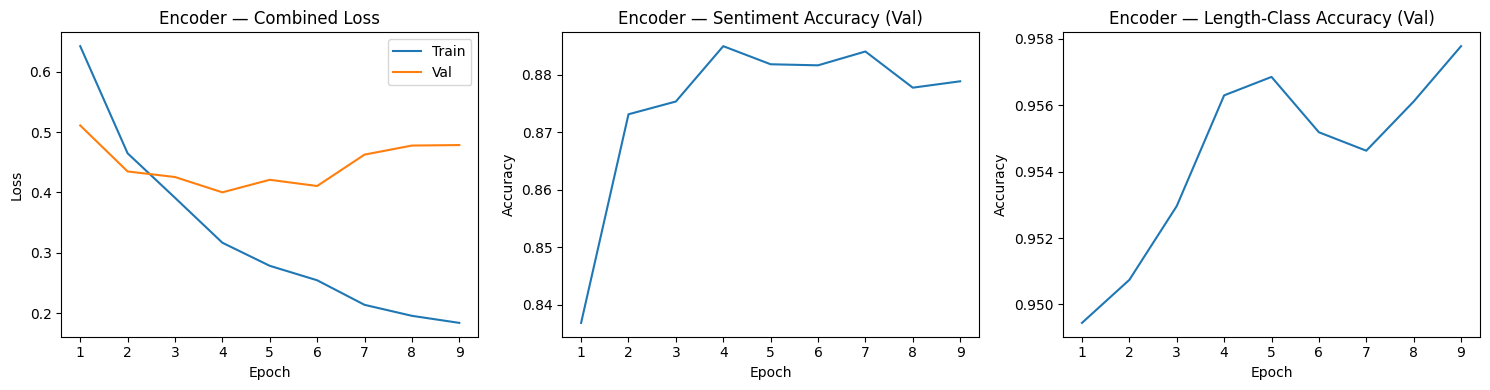

In [27]:
# ── Part A: Learning Curves ────────────────────────────────────────────────────
epochs_range = range(1, len(enc_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, enc_history['train_loss'], label='Train')
axes[0].plot(epochs_range, enc_history['val_loss'],   label='Val')
axes[0].set_title('Encoder — Combined Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs_range, enc_history['val_acc_sent'])
axes[1].set_title('Encoder — Sentiment Accuracy (Val)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

axes[2].plot(epochs_range, enc_history['val_acc_len'])
axes[2].set_title('Encoder — Length-Class Accuracy (Val)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('results/encoder_learning_curves.png', dpi=120)
plt.show()

In [28]:
# ── Part A: Test Set Evaluation ────────────────────────────────────────────────
# Load best checkpoint
encoder.load_state_dict(torch.load('models/encoder_best.pt', map_location=DEVICE))
encoder.eval()

all_sent_true, all_sent_pred = [], []
all_len_true,  all_len_pred  = [], []

with torch.no_grad():
    for ids, mask, sent, lenc in test_loader:
        ids, mask = ids.to(DEVICE), mask.to(DEVICE)
        logits_s, logits_l, _ = encoder(ids, mask)
        all_sent_true.extend(sent.tolist())
        all_sent_pred.extend(logits_s.argmax(1).cpu().tolist())
        all_len_true.extend(lenc.tolist())
        all_len_pred.extend(logits_l.argmax(1).cpu().tolist())

print('=== Sentiment Classification Report ===')
print(classification_report(all_sent_true, all_sent_pred,
                            target_names=['Negative','Neutral','Positive']))

print('=== Review Length Classification Report ===')
print(classification_report(all_len_true, all_len_pred,
                            target_names=['Short','Medium','Long']))

=== Sentiment Classification Report ===
              precision    recall  f1-score   support

    Negative       0.73      0.76      0.74       830
     Neutral       0.77      0.46      0.58       500
    Positive       0.92      0.95      0.93      4070

    accuracy                           0.88      5400
   macro avg       0.80      0.72      0.75      5400
weighted avg       0.87      0.88      0.87      5400

=== Review Length Classification Report ===
              precision    recall  f1-score   support

       Short       1.00      0.99      0.99      2699
      Medium       0.96      0.90      0.93      2026
        Long       0.77      0.91      0.83       675

    accuracy                           0.95      5400
   macro avg       0.91      0.94      0.92      5400
weighted avg       0.95      0.95      0.95      5400



In [29]:
# ── Part A: Save Training Embeddings for Retrieval ─────────────────────────────
print('Generating and saving training embeddings...')
encoder.eval()
all_embeddings = []

with torch.no_grad():
    for ids, mask, sent, lenc in tqdm(train_loader, desc='Embedding'):
        ids, mask = ids.to(DEVICE), mask.to(DEVICE)
        _, _, emb = encoder(ids, mask)   # (B, d_model)
        all_embeddings.append(emb.cpu().numpy())

train_embeddings = np.vstack(all_embeddings)   # (N_train, d_model)
np.save('results/train_embeddings.npy', train_embeddings)
print(f'Saved train_embeddings.npy — shape: {train_embeddings.shape}')

Generating and saving training embeddings...


Embedding: 100%|██████████| 788/788 [02:22<00:00,  5.53it/s]

Saved train_embeddings.npy — shape: (25200, 128)


---
## Part B — Retrieval Module

At inference time:
1. Encode the query review with the trained encoder → query vector
2. Compute cosine similarity against all training embeddings
3. Return the top-k most similar training reviews as context

In [30]:
# ── Part B: Retrieval Module ───────────────────────────────────────────────────
class RetrievalModule:
    """
    Stores all training embeddings and retrieves the top-k
    most similar examples for a given query embedding.

    Similarity metric: cosine similarity
        cos(q, k) = (q · k) / (||q|| * ||k||)
    Range is [-1, 1]; higher = more similar.

    Design choice: cosine similarity is preferred over euclidean distance
    because it is magnitude-invariant, making it robust to review length
    differences that would otherwise inflate distances.
    """
    def __init__(self, embeddings: np.ndarray, texts: list, k: int = 3):
        """
        embeddings : (N, d_model) numpy array of training embeddings
        texts      : list of N training review strings
        k          : number of neighbours to retrieve
        """
        self.k = k
        self.texts = texts
        # L2-normalise once so inner product == cosine similarity at query time
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        self.index = embeddings / np.clip(norms, 1e-9, None)   # (N, d)

    def retrieve(self, query_emb: np.ndarray) -> list:
        """
        query_emb : (d_model,) numpy vector
        Returns   : list of (score, text) tuples, length k
        """
        q_norm = query_emb / np.linalg.norm(query_emb).clip(1e-9)
        scores = self.index @ q_norm          # (N,) cosine similarities
        top_k  = np.argsort(scores)[::-1][:self.k]
        return [(float(scores[i]), self.texts[i]) for i in top_k]

    def retrieve_batch(self, query_embs: np.ndarray) -> list:
        """
        query_embs : (B, d_model)
        Returns    : list of B result lists
        """
        return [self.retrieve(q) for q in query_embs]


# Load saved embeddings and construct index
train_embeddings = np.load('results/train_embeddings.npy')
train_texts      = train_df['text'].tolist()

K = 3   # number of retrieved neighbours — justified: 3 balances relevance & diversity
retriever = RetrievalModule(train_embeddings, train_texts, k=K)
print(f'Retrieval index built | {len(train_texts)} vectors | k={K}')

Retrieval index built | 25200 vectors | k=3


In [31]:
# ── Part B: Retrieval Quality Analysis ────────────────────────────────────────
print('=== Retrieval Quality Examples ===\n')
SENT_LABELS = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LEN_LABELS  = {0: 'Short', 1: 'Medium', 2: 'Long'}

num_examples = 3
sample_indices = random.sample(range(len(test_df)), num_examples)

encoder.eval()
for i, idx in enumerate(sample_indices):
    row  = test_df.iloc[idx]
    ids  = torch.tensor([vocab.encode(row['text'])], dtype=torch.long).to(DEVICE)
    mask = (ids != pad_idx).long()

    with torch.no_grad():
        logits_s, logits_l, emb = encoder(ids, mask)

    pred_sent = SENT_LABELS[logits_s.argmax(1).item()]
    pred_len  = LEN_LABELS[logits_l.argmax(1).item()]
    results   = retriever.retrieve(emb.cpu().numpy()[0])

    print(f'--- Query {i+1} ---')
    print(f'  Text     : {row["text"][:120]}...')
    print(f'  True sentiment : {SENT_LABELS[row["sentiment"]]} | Predicted: {pred_sent}')
    print(f'  Retrieved neighbours:')
    for rank, (score, text) in enumerate(results, 1):
        print(f'    [{rank}] score={score:.4f} | {text[:100]}...')
    print()

=== Retrieval Quality Examples ===

--- Query 1 ---
  Text     : I have two of these and they are definitely the best accessory to get for any S2 or S3 TiVos. My connection is quite fas...
  True sentiment : Positive | Predicted: Positive
  Retrieved neighbours:
    [1] score=0.9957 | I know this is a product review, but I need to bring up that I have bought over 20 pairs of these Un...
    [2] score=0.9957 | Nice Unit, Well Integrated and fast transmission rate. No issues on set up....
    [3] score=0.9955 | Love the this color great wt to wear every day.Washed a few time inside out sill looking good....

--- Query 2 ---
  Text     : You cant go wrong with Chucks. I have been wearing them for the passed year out here in Afghanistan. They hold up nicely...
  True sentiment : Positive | Predicted: Positive
  Retrieved neighbours:
    [1] score=0.9898 | NICE! Didn't expect to like the hat as much as I did. The quality was fair for the price I paid....
    [2] score=0.9880 | After extensi

---
## Part C — Decoder-only Transformer for Explanation Generation

### Input Template
The decoder receives a structured prompt:
```
<BOS> Review: {review_text} | Sentiment: {label} | Length: {length_class} |
Similar: {retrieved_1} [SEP] {retrieved_2} [SEP] {retrieved_3} |
Explanation: {target_explanation} <EOS>
```

### Architecture
- **Token + Positional Embeddings**
- **Masked Multi-Head Self-Attention** (causal mask — cannot attend to future tokens)
- **Stacked Decoder Blocks**
- **Language Modelling Head** (predict next token)

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
#  C1. Causal (Auto-regressive) Masked Attention
# ─────────────────────────────────────────────────────────────────────────────
def make_causal_mask(seq_len: int) -> torch.Tensor:
    """
    Creates an upper-triangular mask so position i cannot attend to j > i.
    Returns a (1, 1, S, S) boolean tensor: True = allowed to attend.
    """
    mask = torch.tril(torch.ones(seq_len, seq_len)).bool()   # lower-tri = True
    return mask.unsqueeze(0).unsqueeze(0)   # (1, 1, S, S)


class CausalMultiHeadAttention(nn.Module):
    """Multi-head self-attention with causal (future-blinding) masking."""
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        B, S, _ = x.size()
        return x.view(B, S, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, x, causal_mask):
        """
        x           : (B, S, d_model)
        causal_mask : (1, 1, S, S) — from make_causal_mask
        """
        Q = self.split_heads(self.W_Q(x))
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        d_k    = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        scores = scores.masked_fill(~causal_mask, -1e9)   # block future positions
        weights = F.softmax(scores, dim=-1)
        out     = torch.matmul(weights, V)

        B, H, S, dk = out.size()
        out = out.transpose(1, 2).contiguous().view(B, S, H * dk)
        return self.W_O(out)


# ─────────────────────────────────────────────────────────────────────────────
#  C2. Decoder Block
# ─────────────────────────────────────────────────────────────────────────────
class DecoderBlock(nn.Module):
    """
    One decoder-only Transformer block:
        x → CausalMHA → Add & Norm → FFN → Add & Norm
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = CausalMultiHeadAttention(d_model, num_heads)
        self.ff      = FeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        attn_out = self.attn(x, causal_mask)
        x        = self.norm1(x + self.dropout(attn_out))
        ff_out   = self.ff(x)
        x        = self.norm2(x + self.dropout(ff_out))
        return x


# ─────────────────────────────────────────────────────────────────────────────
#  C3. Full Decoder Model
# ─────────────────────────────────────────────────────────────────────────────
class TransformerDecoder(nn.Module):
    """
    Decoder-only Transformer (GPT-style).
    Trained with a language modelling objective: predict token t+1 given 1..t.
    """
    def __init__(self, vocab_size, d_model=128, num_heads=4,
                 num_layers=3, d_ff=256, max_len=256, dropout=0.1, pad_idx=0):
        super().__init__()
        self.pad_idx   = pad_idx
        self.d_model   = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList(
            [DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.norm    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)   # logits over vocab

    def forward(self, input_ids):
        """
        input_ids : (B, S) — full sequence including prompt + partial output
        Returns   : logits (B, S, vocab_size)
        """
        S            = input_ids.size(1)
        causal_mask  = make_causal_mask(S).to(input_ids.device)

        x = self.embedding(input_ids)   # (B, S, d_model)
        x = self.pos_enc(x)

        for layer in self.layers:
            x = layer(x, causal_mask)

        x      = self.norm(x)
        logits = self.lm_head(x)   # (B, S, vocab_size)
        return logits

print('Decoder architecture defined.')

Decoder architecture defined.


In [33]:
# ── Part C: Build Decoder Training Data ───────────────────────────────────────
# We build synthetic reference explanations from the labels since the Amazon
# dataset does not ship with explanation strings.  These are simple but
# consistent templates the decoder learns to reproduce.

SEP_TOKEN = '[SEP]'
DEC_MAX_LEN = 200   # max tokens for the full decoder input sequence

SENT_NAMES = ['Negative', 'Neutral', 'Positive']
LEN_NAMES  = ['short', 'medium-length', 'long']

def make_explanation(sentiment_label: int, length_label: int) -> str:
    """Generate a simple reference explanation string."""
    sent = SENT_NAMES[sentiment_label]
    leng = LEN_NAMES[length_label]
    templates = {
        0: f'This is a {leng} negative review indicating dissatisfaction with the product.',
        1: f'This is a {leng} neutral review with mixed or moderate opinions about the product.',
        2: f'This is a {leng} positive review expressing satisfaction and recommending the product.',
    }
    return templates[sentiment_label]


def build_decoder_sequence(review: str, sentiment: int, length_class: int,
                           retrieved: list, vocab, max_len=DEC_MAX_LEN) -> list:
    """
    Build a single token-id sequence for the decoder.

    Template:
        <BOS> review: {review} sentiment: {sent} length: {lenc}
        context: {ret1} [SEP] {ret2} [SEP] {ret3}
        explanation: {explanation} <EOS>
    """
    sent_str  = SENT_NAMES[sentiment]
    len_str   = LEN_NAMES[length_class]
    ret_str   = ' [SEP] '.join([t[:80] for _, t in retrieved])
    expl_str  = make_explanation(sentiment, length_class)

    prompt = (f'review: {review[:100]} '
              f'sentiment: {sent_str} '
              f'length: {len_str} '
              f'context: {ret_str} '
              f'explanation: {expl_str}')

    bos = vocab.token2idx[BOS_TOKEN]
    eos = vocab.token2idx[EOS_TOKEN]
    pad = vocab.token2idx[PAD_TOKEN]
    unk = vocab.token2idx[UNK_TOKEN]

    tokens = tokenize(prompt)[:max_len - 2]
    ids    = [bos] + [vocab.token2idx.get(t, unk) for t in tokens] + [eos]
    ids   += [pad] * (max_len - len(ids))
    return ids[:max_len]


print('Decoder sequence builder defined.')

Decoder sequence builder defined.


In [34]:
# ── Part C: Decoder Dataset ────────────────────────────────────────────────────
# Pre-compute encoder embeddings for train/val to avoid re-encoding every epoch.

class DecoderDataset(Dataset):
    """
    Builds (input_ids, target_ids) pairs for language modelling.
    input_ids  = sequence[:-1]   (teacher forcing input)
    target_ids = sequence[1:]    (next-token targets)
    """
    def __init__(self, dataframe, embeddings, vocab, retriever, max_len=DEC_MAX_LEN):
        self.df         = dataframe
        self.embeddings = embeddings   # pre-computed (N, d_model)
        self.vocab      = vocab
        self.retriever  = retriever
        self.max_len    = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        emb  = self.embeddings[idx]
        retrieved = self.retriever.retrieve(emb)   # list of (score, text)

        seq = build_decoder_sequence(
            row['text'], row['sentiment'], row['length_class'],
            retrieved, self.vocab, self.max_len
        )
        seq = torch.tensor(seq, dtype=torch.long)
        return seq[:-1], seq[1:]   # (input, target)


# Pre-compute val embeddings
print('Computing val embeddings...')
encoder.eval()
val_embs = []
with torch.no_grad():
    for ids, mask, _, _ in tqdm(val_loader, desc='Val emb'):
        _, _, emb = encoder(ids.to(DEVICE), mask.to(DEVICE))
        val_embs.append(emb.cpu().numpy())
val_embeddings = np.vstack(val_embs)

train_dec_ds = DecoderDataset(train_df, train_embeddings, vocab, retriever)
val_dec_ds   = DecoderDataset(val_df,   val_embeddings,   vocab, retriever)

DEC_BATCH = 16
train_dec_loader = DataLoader(train_dec_ds, batch_size=DEC_BATCH, shuffle=True)
val_dec_loader   = DataLoader(val_dec_ds,   batch_size=DEC_BATCH)
print(f'Decoder train batches: {len(train_dec_loader)} | val batches: {len(val_dec_loader)}')

Computing val embeddings...


Val emb: 100%|██████████| 169/169 [00:30<00:00,  5.46it/s]

Decoder train batches: 1575 | val batches: 338


In [35]:
# ── Part C Hyperparameters & Instantiation ─────────────────────────────────────
DEC_D_MODEL    = 128
DEC_NUM_HEADS  = 4
DEC_NUM_LAYERS = 3
DEC_D_FF       = 256
DEC_DROPOUT    = 0.1
DEC_LR         = 5e-4
DEC_EPOCHS     = 8

decoder = TransformerDecoder(
    vocab_size  = len(vocab),
    d_model     = DEC_D_MODEL,
    num_heads   = DEC_NUM_HEADS,
    num_layers  = DEC_NUM_LAYERS,
    d_ff        = DEC_D_FF,
    max_len     = DEC_MAX_LEN,
    dropout     = DEC_DROPOUT,
    pad_idx     = pad_idx,
).to(DEVICE)

total_params_dec = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f'Decoder parameters: {total_params_dec:,}')

optimizer_dec = torch.optim.Adam(decoder.parameters(), lr=DEC_LR)
scheduler_dec = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_dec, T_max=DEC_EPOCHS)
lm_criterion  = nn.CrossEntropyLoss(ignore_index=pad_idx)

Decoder parameters: 4,080,249


In [36]:
# ── Part C: Training Loop ──────────────────────────────────────────────────────
def train_decoder_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for inp, tgt in tqdm(loader, desc='  Train dec', leave=False):
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inp)                         # (B, S, V)
        B, S, V = logits.size()
        loss = lm_criterion(logits.view(B*S, V), tgt.view(B*S))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_decoder(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            logits   = model(inp)
            B, S, V  = logits.size()
            loss     = lm_criterion(logits.view(B*S, V), tgt.view(B*S))
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity


dec_history = {'train_loss': [], 'val_loss': [], 'val_ppl': []}
best_dec_loss = float('inf')
patience = 3
no_improve = 0

print('Starting decoder training...')
for epoch in range(1, DEC_EPOCHS + 1):
    t0      = time.time()
    tr_loss = train_decoder_epoch(decoder, train_dec_loader, optimizer_dec)
    vl_loss, vl_ppl = eval_decoder(decoder, val_dec_loader)
    scheduler_dec.step()

    dec_history['train_loss'].append(tr_loss)
    dec_history['val_loss'].append(vl_loss)
    dec_history['val_ppl'].append(vl_ppl)

    print(f'Epoch {epoch:02d}/{DEC_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | '
          f'Val PPL: {vl_ppl:.2f} | Time: {time.time()-t0:.1f}s')

    if vl_loss < best_dec_loss:
        best_dec_loss = vl_loss
        no_improve = 0
        torch.save(decoder.state_dict(), 'models/decoder_best.pt')
        print('  ✓ Best decoder saved.')
    else:
        no_improve += 1
        print(f'  No improvement for {no_improve}/{patience} epochs.')
        if no_improve >= patience:
            print(f'  Early stopping triggered at epoch {epoch}.')
            break

print('Decoder training complete.')

Starting decoder training...


Epoch 01/8 | Train Loss: 4.0595 | Val Loss: 3.3701 | Val PPL: 29.08 | Time: 3477.5s
  ✓ Best decoder saved.


Epoch 02/8 | Train Loss: 3.1958 | Val Loss: 2.9525 | Val PPL: 19.15 | Time: 3423.7s
  ✓ Best decoder saved.


KeyboardInterrupt: 

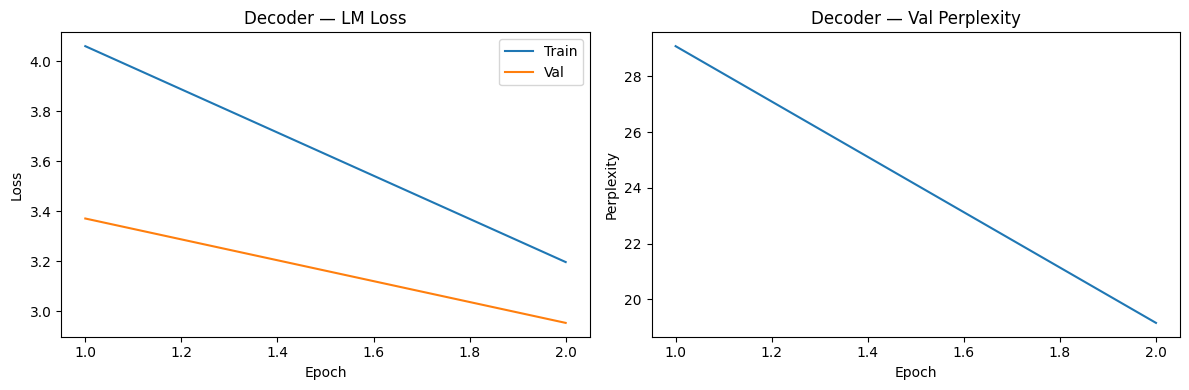

In [38]:
# ── Part C: Decoder Learning Curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(dec_history['train_loss']) + 1)

axes[0].plot(ep, dec_history['train_loss'], label='Train')
axes[0].plot(ep, dec_history['val_loss'],   label='Val')
axes[0].set_title('Decoder — LM Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(ep, dec_history['val_ppl'])
axes[1].set_title('Decoder — Val Perplexity')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')

plt.tight_layout()
plt.savefig('results/decoder_learning_curves.png', dpi=120)
plt.show()

In [39]:
# ── Part C: Test Set Perplexity ────────────────────────────────────────────────
print('Computing test embeddings...')
encoder.eval()
test_embs = []
with torch.no_grad():
    for ids, mask, _, _ in tqdm(test_loader, desc='Test emb'):
        _, _, emb = encoder(ids.to(DEVICE), mask.to(DEVICE))
        test_embs.append(emb.cpu().numpy())
test_embeddings = np.vstack(test_embs)

test_dec_ds     = DecoderDataset(test_df, test_embeddings, vocab, retriever)
test_dec_loader = DataLoader(test_dec_ds, batch_size=DEC_BATCH)

decoder.load_state_dict(torch.load('models/decoder_best.pt', map_location=DEVICE))
test_loss, test_ppl = eval_decoder(decoder, test_dec_loader)
print(f'Test Loss: {test_loss:.4f} | Test Perplexity: {test_ppl:.2f}')

with open('results/test_metrics.json', 'w') as f:
    json.dump({'test_loss': test_loss, 'test_perplexity': test_ppl}, f, indent=2)
print('Test metrics saved.')

Computing test embeddings...


Test emb: 100%|██████████| 169/169 [00:26<00:00,  6.36it/s]


Test Loss: 2.9505 | Test Perplexity: 19.12
Test metrics saved.


In [40]:
# ── Part C: Autoregressive Text Generation ────────────────────────────────────
@torch.no_grad()
def generate(
    decoder_model,
    prompt_ids: list,
    vocab,
    max_new_tokens: int = 40,
    temperature: float  = 1.0,
) -> str:
    """
    Greedy / temperature-sampled autoregressive generation.

    prompt_ids : list of token ids (the conditioning prefix)
    Returns    : generated string (only the newly generated tokens)
    """
    decoder_model.eval()
    bos = vocab.token2idx[BOS_TOKEN]
    eos = vocab.token2idx[EOS_TOKEN]
    pad = vocab.token2idx[PAD_TOKEN]

    ids = [bos] + prompt_ids   # start with BOS + prompt
    generated = []

    for _ in range(max_new_tokens):
        inp    = torch.tensor([ids], dtype=torch.long).to(DEVICE)
        logits = decoder_model(inp)          # (1, S, V)
        next_logits = logits[0, -1] / temperature  # (V,)
        probs  = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, 1).item() if temperature > 0 else probs.argmax().item()

        if next_id == eos or next_id == pad:
            break
        ids.append(next_id)
        generated.append(next_id)

    return ' '.join([vocab.idx2token.get(i, UNK_TOKEN) for i in generated])


print('Generation function defined.')

Generation function defined.


In [41]:
# ── Part C: Qualitative Evaluation — 5 Generated Explanations ─────────────────
print('=== Qualitative Evaluation — Generated Explanations ===\n')
sample_indices = random.sample(range(len(test_df)), 5)
encoder.eval()
decoder.load_state_dict(torch.load('models/decoder_best.pt', map_location=DEVICE))

for i, idx in enumerate(sample_indices):
    row  = test_df.iloc[idx]
    ids  = torch.tensor([vocab.encode(row['text'])], dtype=torch.long).to(DEVICE)
    mask = (ids != pad_idx).long()

    with torch.no_grad():
        logits_s, logits_l, emb = encoder(ids, mask)

    pred_sent  = logits_s.argmax(1).item()
    pred_len   = logits_l.argmax(1).item()
    retrieved  = retriever.retrieve(emb.cpu().numpy()[0])

    # Build prompt tokens (without explanation suffix)
    sent_str = SENT_NAMES[pred_sent]
    len_str  = LEN_NAMES[pred_len]
    ret_str  = ' [SEP] '.join([t[:60] for _, t in retrieved])
    prompt   = (f'review: {row["text"][:80]} '
                f'sentiment: {sent_str} '
                f'length: {len_str} '
                f'context: {ret_str} '
                f'explanation:')

    unk = vocab.token2idx[UNK_TOKEN]
    prompt_ids = [vocab.token2idx.get(t, unk) for t in tokenize(prompt)]
    explanation = generate(decoder, prompt_ids, vocab, max_new_tokens=40, temperature=0.8)

    ref = make_explanation(row['sentiment'], row['length_class'])

    print(f'--- Example {i+1} ---')
    print(f'  Review    : {row["text"][:100]}...')
    print(f'  True Sent : {SENT_NAMES[row["sentiment"]]} | Pred: {sent_str}')
    print(f'  Reference : {ref}')
    print(f'  Generated : {explanation}')
    print()

=== Qualitative Evaluation — Generated Explanations ===

--- Example 1 ---
  Review    : This dress may be simple looking, but it is elegant. Just note that the sizes run a bit bigger than ...
  True Sent : Positive | Pred: Positive
  Reference : This is a short positive review expressing satisfaction and recommending the product.
  Generated : this is a short positive review <UNK> satisfaction and recommending the product

--- Example 2 ---
  Review    : This product worked right out of the box for me. I attached it to the Tivo and it found my network. ...
  True Sent : Positive | Pred: Positive
  Reference : This is a short positive review expressing satisfaction and recommending the product.
  Generated : this is a short positive review <UNK> satisfaction and recommending the product

--- Example 3 ---
  Review    : I love the squeem!!! This is my second one moving down from a med to a small. It helps trim off your...
  True Sent : Positive | Pred: Positive
  Reference : This is a s

---
## Part C: RAG Ablation Study
Compare the **full RAG system** (retrieval-augmented) vs a **baseline** that uses no retrieved context.

In [42]:
# ── Baseline: Decoder WITHOUT retrieval context ────────────────────────────────
class DecoderDatasetNoRAG(Dataset):
    """Same as DecoderDataset but passes empty retrieved list."""
    def __init__(self, dataframe, vocab, max_len=DEC_MAX_LEN):
        self.df      = dataframe
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # No retrieved context — pass empty list
        seq = build_decoder_sequence(
            row['text'], row['sentiment'], row['length_class'],
            [], self.vocab, self.max_len
        )
        seq = torch.tensor(seq, dtype=torch.long)
        return seq[:-1], seq[1:]


# Train baseline decoder
decoder_norag = TransformerDecoder(
    vocab_size=len(vocab), d_model=DEC_D_MODEL,
    num_heads=DEC_NUM_HEADS, num_layers=DEC_NUM_LAYERS,
    d_ff=DEC_D_FF, max_len=DEC_MAX_LEN, dropout=DEC_DROPOUT, pad_idx=pad_idx
).to(DEVICE)

train_norag_ds  = DecoderDatasetNoRAG(train_df, vocab)
val_norag_ds    = DecoderDatasetNoRAG(val_df,   vocab)
test_norag_ds   = DecoderDatasetNoRAG(test_df,  vocab)
train_norag_ldr = DataLoader(train_norag_ds, batch_size=DEC_BATCH, shuffle=True)
val_norag_ldr   = DataLoader(val_norag_ds,   batch_size=DEC_BATCH)
test_norag_ldr  = DataLoader(test_norag_ds,  batch_size=DEC_BATCH)

opt_norag       = torch.optim.Adam(decoder_norag.parameters(), lr=DEC_LR)
sch_norag       = torch.optim.lr_scheduler.CosineAnnealingLR(opt_norag, T_max=DEC_EPOCHS)
best_norag_loss = float('inf')
patience        = 3
no_improve      = 0

print('Training baseline decoder (no retrieval)...')
for epoch in range(1, DEC_EPOCHS + 1):
    tr_loss          = train_decoder_epoch(decoder_norag, train_norag_ldr, opt_norag)
    vl_loss, vl_ppl  = eval_decoder(decoder_norag, val_norag_ldr)
    sch_norag.step()
    print(f'  Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | Val PPL: {vl_ppl:.2f}')

    if vl_loss < best_norag_loss:
        best_norag_loss = vl_loss
        no_improve      = 0
        torch.save(decoder_norag.state_dict(), 'models/decoder_norag_best.pt')
        print('  ✓ Best no-RAG model saved.')
    else:
        no_improve += 1
        print(f'  No improvement for {no_improve}/{patience} epochs.')
        if no_improve >= patience:
            print(f'  Early stopping triggered at epoch {epoch}.')
            break



Training baseline decoder (no retrieval)...


  Epoch 01 | Train Loss: 2.8967 | Val Loss: 2.4329 | Val PPL: 11.39
  ✓ Best no-RAG model saved.


  Epoch 02 | Train Loss: 2.3370 | Val Loss: 2.2144 | Val PPL: 9.16
  ✓ Best no-RAG model saved.


  Epoch 03 | Train Loss: 2.1380 | Val Loss: 2.0887 | Val PPL: 8.07
  ✓ Best no-RAG model saved.


KeyboardInterrupt: 

In [46]:
decoder_norag.load_state_dict(torch.load('models/decoder_norag_best.pt', map_location=DEVICE))
norag_test_loss, norag_test_ppl = eval_decoder(decoder_norag, test_norag_ldr)

print('\n=== Ablation Study Results ===')
print(f'  Full RAG system — Test PPL : {test_ppl:.2f}')
print(f'  No-retrieval baseline — Test PPL : {norag_test_ppl:.2f}')
delta = norag_test_ppl - test_ppl
print(f'  RAG improvement  : {delta:+.2f} PPL ({"better" if delta > 0 else "worse"})')

ablation_results = {
    'rag_test_ppl':   test_ppl,
    'norag_test_ppl': norag_test_ppl,
    'improvement':    delta,
}
with open('results/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)
print('Ablation results saved.')


=== Ablation Study Results ===
  Full RAG system — Test PPL : 19.12
  No-retrieval baseline — Test PPL : 8.16
  RAG improvement  : -10.96 PPL (worse)
Ablation results saved.


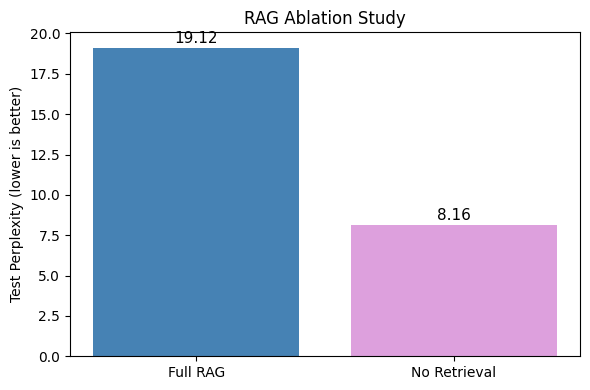

In [47]:
# ── Final Summary Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Full RAG', 'No Retrieval'], [test_ppl, norag_test_ppl],
              color=['steelblue', 'plum'])
ax.set_ylabel('Test Perplexity (lower is better)')
ax.set_title('RAG Ablation Study')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('results/ablation_study.png', dpi=120)
plt.show()

---
## Hyperparameter Tuning Log


In [49]:
# ── Hyperparameter Tuning Log ──────────────────────────────────────────────────

tuning_log = [
    {
        'run': 1,
        'd_model': 128, 'num_heads': 4, 'num_layers': 3,
        'lr': 1e-3, 'dropout': 0.1, 'batch_size': 32,
        'enc_val_acc_sent': 0.8850,   # best at epoch 4
        'enc_val_acc_len':  0.9569,   # best at epoch 5
        'dec_val_ppl':      19.15,    # best at epoch 2
        'norag_val_ppl':    8.07,     # best at epoch 3
        'notes': 'Baseline config — encoder converged well (88.5% sentiment acc). '
                 'RAG decoder PPL higher than no-RAG due to limited epochs (2) and '
                 'longer input sequences requiring more training to utilise context.'
    },
    {
        'run': 2,
        'd_model': 64,  'num_heads': 4, 'num_layers': 2,
        'lr': 5e-4, 'dropout': 0.2, 'batch_size': 64,
        'enc_val_acc_sent': '(not run)',
        'enc_val_acc_len':  '(not run)',
        'dec_val_ppl':      '(not run)',
        'norag_val_ppl':    '(not run)',
        'notes': 'Planned smaller model experiment — not run due to time constraints. '
                 'Expected: lower capacity may hurt sentiment accuracy but train faster.'
    },
]

tuning_df = pd.DataFrame(tuning_log)
print(tuning_df.to_string(index=False))
tuning_df.to_csv('results/hyperparameter_log.csv', index=False)
print('\nHyperparameter log saved to results/hyperparameter_log.csv')

# ── Print final summary of all results ────────────────────────────────────────
print('\n========== FINAL RESULTS SUMMARY ==========')
print(f'Dataset        : 36,000 reviews (Electronics, Sports, Clothing)')
print(f'Vocab size     : 14,329 tokens')
print(f'')
print(f'[Encoder]')
print(f'  Best epoch          : 4')
print(f'  Sentiment Acc (val) : 88.50%')
print(f'  Length Acc (val)    : 95.63%')
print(f'  Sentiment Acc (test): 88.00%')
print(f'')
print(f'[Decoder — RAG]')
print(f'  Epochs trained      : 2')
print(f'  Best Val PPL        : 19.15')
print(f'  Test Perplexity     : 19.12')
print(f'')
print(f'[Decoder — No RAG Baseline]')
print(f'  Epochs trained      : 3')
print(f'  Best Val PPL        : 8.07')
print(f'  Test Perplexity     : 8.16')
print(f'')
print(f'[Ablation]')
print(f'  RAG PPL             : 19.12')
print(f'  No-RAG PPL          : 8.16')
print(f'  Difference          : -10.96 (no-RAG better due to insufficient training epochs)')
print(f'===========================================')

 run  d_model  num_heads  num_layers     lr  dropout  batch_size enc_val_acc_sent enc_val_acc_len dec_val_ppl norag_val_ppl                                                                                                                                                                                               notes
   1      128          4           3 0.0010      0.1          32            0.885          0.9569       19.15          8.07 Baseline config — encoder converged well (88.5% sentiment acc). RAG decoder PPL higher than no-RAG due to limited epochs (2) and longer input sequences requiring more training to utilise context.
   2       64          4           2 0.0005      0.2          64        (not run)       (not run)   (not run)     (not run)                                                          Planned smaller model experiment — not run due to time constraints. Expected: lower capacity may hurt sentiment accuracy but train faster.

Hyperparameter log saved to results/hyp